# RO Settlement Summary

Short version: keep FBMC and NTC, show one compact table, two figures, and a small illustrative event snapshot.
Set `SELECTED_DESIGNS` to `["FBMC"]` if you want only the thesis focus case.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Liberation Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.25,
    'grid.linewidth': 0.6,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.unicode_minus': False,
})
EURO = '€'  # euro sign

REPO_DIR = Path(r'c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis')
RESULTS_DIR = REPO_DIR / 'RO_Settlement' / 'Results'
FIGURES_DIR = RESULTS_DIR / 'Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = True
K = 500
SELECTED_DESIGNS = ['FBMC', 'NTC']  # switch to ['FBMC'] for thesis focus only

events_path = RESULTS_DIR / f'ro_settlement_events_K{K}.csv'
summary_path = RESULTS_DIR / f'ro_settlement_summary_K{K}.csv'

print('Using results folder:', RESULTS_DIR)
print('Using figures folder:', FIGURES_DIR)
print('Events:', events_path)
print('Summary:', summary_path)

if not events_path.exists():
    raise FileNotFoundError(events_path)
if not summary_path.exists():
    raise FileNotFoundError(summary_path)

events = pd.read_csv(events_path, sep=';')
summary = pd.read_csv(summary_path, sep=';')
for df in (events, summary):
    if 'Contract' in df.columns:
        df['Contract'] = df['Contract'].astype(str).str.replace('���', '→', regex=False)
events['PriceSpread'] = events['P_Importer_EUR_per_MWh'] - events['P_Exporter_EUR_per_MWh']

def save_fig(fig, filename):
    out = FIGURES_DIR / filename
    fig.savefig(out, bbox_inches='tight')
    print('Saved figure:', out)
    return out

print(f'Loaded {len(events)} event rows and {len(summary)} summary rows.')


Using results folder: c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis\RO_Settlement\Results
Using figures folder: c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis\RO_Settlement\Results\Figures
Events: c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis\RO_Settlement\Results\ro_settlement_events_K150.csv
Summary: c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis\RO_Settlement\Results\ro_settlement_summary_K150.csv
Loaded 12 event rows and 4 summary rows.


In [11]:
# Compact annual summary for the selected designs
summary_view = summary[summary["Design"].isin(SELECTED_DESIGNS)].copy()
summary_view = summary_view[[
    "Design", "Contract", "Cat1_Hours_Weighted", "Cat2_Hours_Weighted", "Cat3_Hours_Weighted",
    "Annual_HedgeShortfall_MEUR", "Settlement_Outcome"
]]
summary_view = summary_view.sort_values(["Design", "Contract"])
display(
    summary_view.style
    .format({
        "Cat1_Hours_Weighted": "{:.1f}",
        "Cat2_Hours_Weighted": "{:.1f}",
        "Cat3_Hours_Weighted": "{:.1f}",
        "Annual_HedgeShortfall_MEUR": "{:+.4f}",
    })
    .hide(axis="index")
    .set_caption(f"RO settlement summary for selected designs (K = {K} €/MWh)")
)

Design,Contract,Cat1_Hours_Weighted,Cat2_Hours_Weighted,Cat3_Hours_Weighted,Annual_HedgeShortfall_MEUR,Settlement_Outcome
FBMC,A→B,0.0,6.0,0.0,+2.7467,Net under-compensation by RO alone
FBMC,A→C,0.0,6.0,0.0,+5.7557,Net under-compensation by RO alone
NTC,A→B,0.0,6.0,0.0,-0.6190,Net over-compensation by RO alone
NTC,A→C,0.0,6.0,0.0,-0.6842,Net over-compensation by RO alone


Saved figure: c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis\RO_Settlement\Results\Figures\ro_shortfall_by_design_K150.png


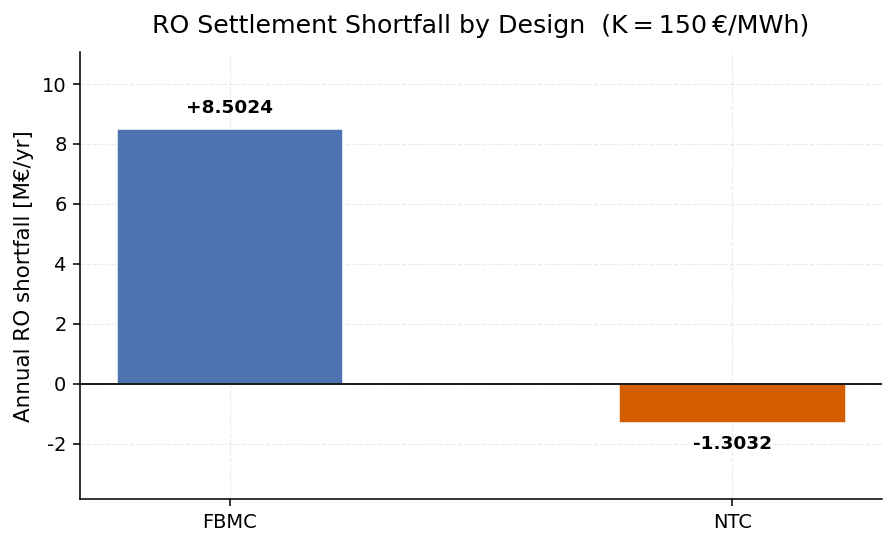

In [12]:
# Figure 1: annual settlement shortfall by design
shortfall_by_design = summary_view.groupby('Design')['Annual_HedgeShortfall_MEUR'].sum().reindex(SELECTED_DESIGNS)
palette = {'FBMC': '#4C72B0', 'NTC': '#D55E00'}
bar_colors = [palette.get(d, '#8A8A8A') for d in shortfall_by_design.index]

fig, ax = plt.subplots(figsize=(6.5, 4.0))
bars = ax.bar(shortfall_by_design.index, shortfall_by_design.values,
              color=bar_colors, width=0.45, edgecolor='white', linewidth=0.8)
ax.axhline(0, color='black', lw=0.9)

yspan = shortfall_by_design.abs().max() or 1e-4
ax.set_ylim(
    shortfall_by_design.min() - 0.30 * yspan,
    shortfall_by_design.max() + 0.30 * yspan,
)

for bar, v in zip(bars, shortfall_by_design.values):
    ax.annotate(
        f'{v:+.4f}',
        xy=(bar.get_x() + bar.get_width() / 2, v),
        xytext=(0, 6 if v >= 0 else -6),
        textcoords='offset points',
        ha='center', va='bottom' if v >= 0 else 'top',
        fontsize=9.5, fontweight='bold',
    )

ax.set_ylabel(f'Annual RO shortfall [M{EURO}/yr]')
ax.set_title(f'RO Settlement Shortfall by Design  (K = {K} {EURO}/MWh)', pad=10)
ax.set_axisbelow(True)
if SAVE_FIGURES:
    save_fig(fig, f'ro_shortfall_by_design_K{K}.png')
plt.tight_layout()
plt.show()


Saved figure: c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis\RO_Settlement\Results\Figures\ro_contract_shortfall_by_design_K150.png


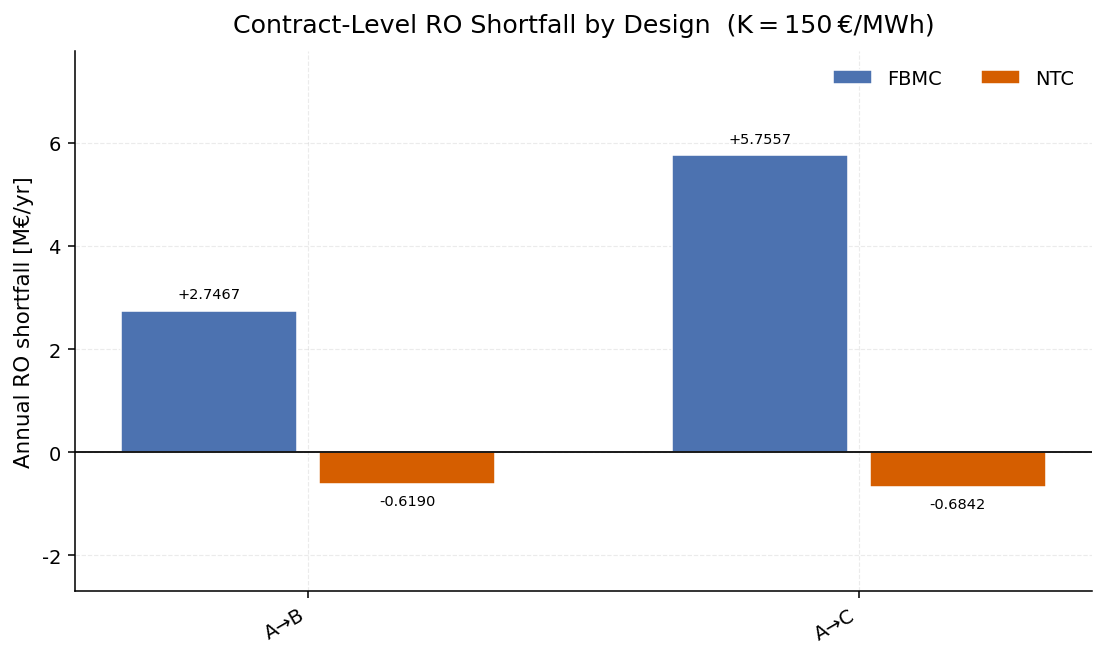

In [13]:
# Figure 2: contract-level shortfall, FBMC vs NTC
contract_view = summary_view.copy()
contract_pivot = contract_view.pivot(
    index='Contract', columns='Design', values='Annual_HedgeShortfall_MEUR'
).reindex(columns=SELECTED_DESIGNS)
contracts = contract_pivot.index.tolist()
n = len(contracts)
n_designs = len(SELECTED_DESIGNS)
width = 0.32 if n_designs > 1 else 0.50

fig_w = max(8, 1.5 * n * n_designs)
fig, ax = plt.subplots(figsize=(fig_w, 4.8))
palette = {'FBMC': '#4C72B0', 'NTC': '#D55E00'}
x = np.arange(n)

all_vals = contract_pivot.values.flatten()
all_vals = all_vals[~np.isnan(all_vals)]
yspan = np.abs(all_vals).max() if len(all_vals) else 1e-4

for idx, design in enumerate(SELECTED_DESIGNS):
    vals = contract_pivot[design].values
    offset = (idx - (n_designs - 1) / 2) * (width + 0.04)
    bars = ax.bar(x + offset, vals, width=width, label=design,
                  color=palette.get(design, '#888888'),
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            ax.annotate(
                f'{v:+.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, v),
                xytext=(0, 5 if v >= 0 else -5),
                textcoords='offset points',
                ha='center', va='bottom' if v >= 0 else 'top',
                fontsize=7.5,
            )

ax.axhline(0, color='black', lw=0.9)
ax.set_ylim(
    (np.nanmin(all_vals) if len(all_vals) else -yspan) - 0.35 * yspan,
    (np.nanmax(all_vals) if len(all_vals) else  yspan) + 0.35 * yspan,
)
ax.set_xticks(x)
ax.set_xticklabels(contracts, rotation=30, ha='right', fontsize=10)
ax.set_ylabel(f'Annual RO shortfall [M{EURO}/yr]')
ax.set_title(f'Contract-Level RO Shortfall by Design  (K = {K} {EURO}/MWh)', pad=10)
ax.legend(frameon=False, ncol=n_designs, loc='upper right', fontsize=10)
ax.set_axisbelow(True)
if SAVE_FIGURES:
    save_fig(fig, f'ro_contract_shortfall_by_design_K{K}.png')
plt.tight_layout()
plt.show()


In [14]:
# Illustrative event snapshot: first few mismatch rows for the selected designs
event_view = events[events['Design'].isin(SELECTED_DESIGNS)].copy()
event_view = event_view[[
    'Design', 'Contract', 'Timestep', 'P_Exporter_EUR_per_MWh', 'P_Importer_EUR_per_MWh',
    'ShortfallType', 'HedgeShortfall_EUR_per_h'
]]
event_view = event_view.sort_values(['Design', 'Contract', 'Timestep'])
display(
    event_view.head(8).style
    .format({
        'P_Exporter_EUR_per_MWh': '{:.2f}',
        'P_Importer_EUR_per_MWh': '{:.2f}',
        'HedgeShortfall_EUR_per_h': '{:.2f}',
    })
)


,Design,Contract,Timestep,P_Exporter_EUR_per_MWh,P_Importer_EUR_per_MWh,ShortfallType,HedgeShortfall_EUR_per_h
0,FBMC,A→B,12,490.19,464.78,Over-compensated,-122264.98
1,FBMC,A→B,18,587.19,948.39,Under-compensated,1738352.99
2,FBMC,A→B,19,628.30,577.87,Over-compensated,-242715.10
3,FBMC,A→C,12,490.19,446.55,Over-compensated,-210023.06
4,FBMC,A→C,18,587.19,1310.28,Under-compensated,3480046.59
5,FBMC,A→C,19,628.30,546.81,Over-compensated,-392195.17
6,NTC,A→B,12,450.68,450.66,Over-compensated,-80.26
7,NTC,A→B,18,541.58,503.39,Over-compensated,-131491.58


## Detailed event view
This figure shows the event-level mechanism behind the aggregate shortfall.

Saved figure: c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis\RO_Settlement\Results\Figures\ro_event_level_shortfall_K150.png


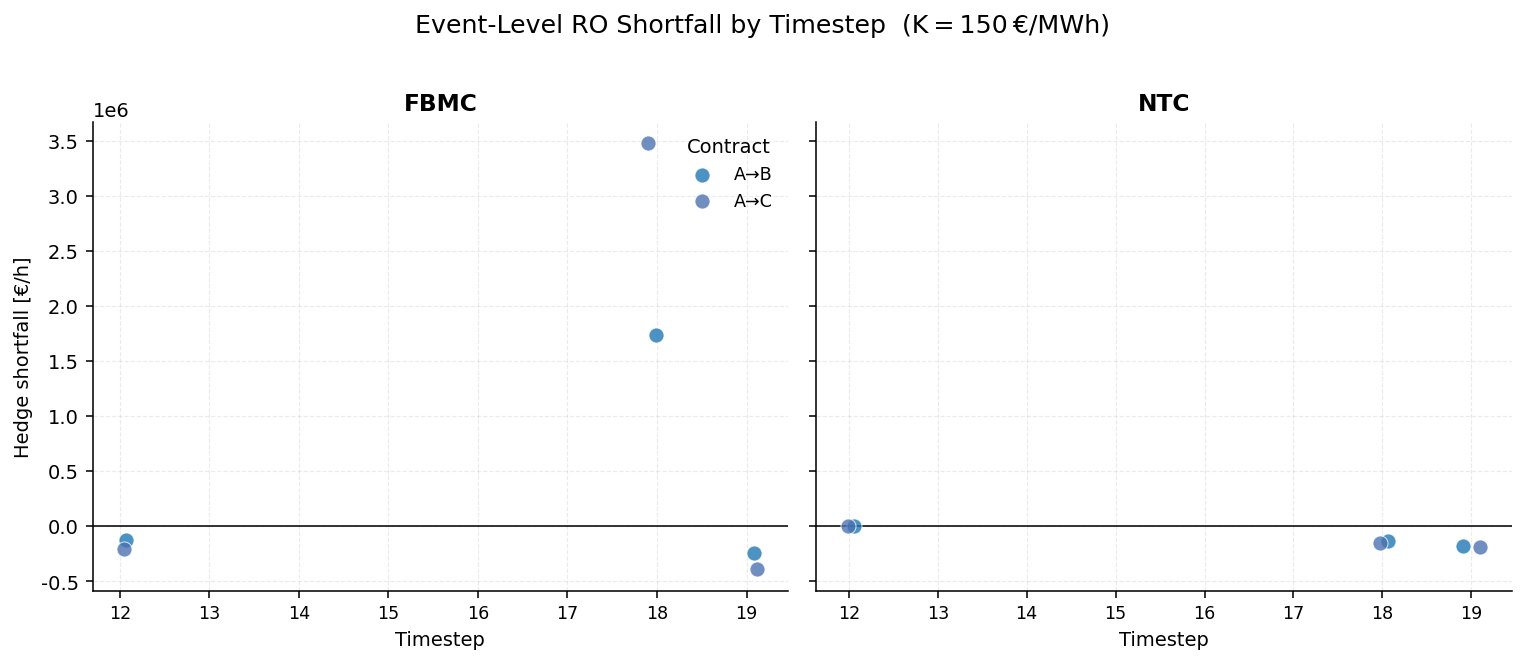

In [15]:
# Figure 3: detailed event-level mechanism
event_detail = events[events['Design'].isin(SELECTED_DESIGNS)].copy()
event_detail = event_detail[event_detail['Category'].notna()]
if event_detail.empty:
    print('No event rows available for the selected designs.')
else:
    contract_colors = {
        'A→C': '#4C72B0', 'B→C': '#D55E00',
        'A->C':   '#4C72B0', 'B->C':   '#D55E00',
    }
    n_designs = len(SELECTED_DESIGNS)
    fig, axes = plt.subplots(1, n_designs,
                              figsize=(max(9, 5.5 * n_designs), 4.6),
                              sharey=True)
    if n_designs == 1:
        axes = [axes]

    rng = np.random.default_rng(42)

    for ax, design in zip(axes, SELECTED_DESIGNS):
        d = event_detail[event_detail['Design'] == design].copy()
        contracts_in_d = sorted(d['Contract'].unique())
        for i, contract in enumerate(contracts_in_d):
            g = d[d['Contract'] == contract]
            jitter = rng.uniform(-0.12, 0.12, size=len(g))
            ax.scatter(
                g['Timestep'].to_numpy() + jitter,
                g['HedgeShortfall_EUR_per_h'],
                s=60, alpha=0.80,
                label=contract,
                color=contract_colors.get(contract, f'C{i}'),
                edgecolor='white', linewidth=0.5, zorder=3,
            )
        ax.axhline(0, color='black', lw=0.8)
        ax.set_title(design, fontsize=12, fontweight='bold')
        ax.set_xlabel('Timestep', fontsize=10)
        ax.tick_params(axis='x', labelsize=9)
        ax.set_axisbelow(True)

    axes[0].set_ylabel(f'Hedge shortfall [{EURO}/h]', fontsize=10)
    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        handles, labels = axes[-1].get_legend_handles_labels()
    axes[0].legend(handles, labels, frameon=False, title='Contract', fontsize=9)
    fig.suptitle(
        f'Event-Level RO Shortfall by Timestep  (K = {K} {EURO}/MWh)',
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    save_fig(fig, f'ro_event_level_shortfall_K{K}.png')
    plt.show()


## Detailed heatmap
This figure shows the annual-weighted shortfall by contract and timestep, with zeros where no settlement event occurs.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23308\3571781428.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure: c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis\RO_Settlement\Results\Figures\ro_heatmap_shortfall_K150.png


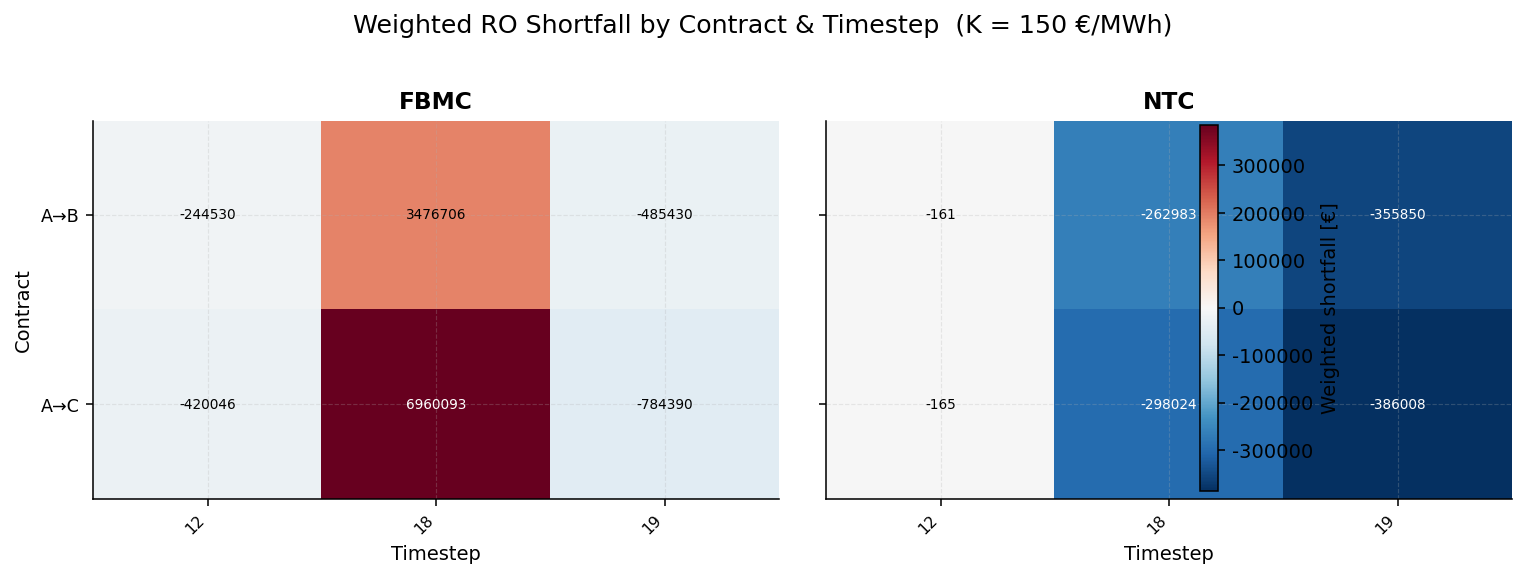

In [16]:
# Figure 4: contract-by-timestep heatmap of weighted shortfall
heat = events[events['Design'].isin(SELECTED_DESIGNS)].copy()
if heat.empty:
    print('No event rows available for the selected designs.')
else:
    designs = SELECTED_DESIGNS
    n_designs = len(designs)
    fig, axes = plt.subplots(1, n_designs,
                              figsize=(max(9, 5.5 * n_designs), 4.0),
                              sharey=True)
    if n_designs == 1:
        axes = [axes]

    last_im = None
    for ax, design in zip(axes, designs):
        d = heat[heat['Design'] == design].copy()
        pivot = d.pivot_table(
            index='Contract', columns='Timestep',
            values='Weighted_Delta_EUR', aggfunc='sum', fill_value=0,
        ).sort_index()
        if pivot.empty:
            ax.axis('off')
            continue
        all_ts = sorted(heat['Timestep'].unique())
        pivot = pivot.reindex(columns=all_ts, fill_value=0)
        vals = pivot.values
        vmax = float(np.max(np.abs(vals))) if np.max(np.abs(vals)) > 0 else 1.0
        last_im = ax.imshow(vals, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                             interpolation='nearest')
        ax.set_title(design, fontsize=12, fontweight='bold')
        ax.set_xticks(np.arange(len(all_ts)))
        ax.set_xticklabels(all_ts, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=9)
        ax.set_xlabel('Timestep', fontsize=10)
        for row in range(vals.shape[0]):
            for col in range(vals.shape[1]):
                v = vals[row, col]
                if v != 0:
                    ax.text(col, row, f'{v:.0f}', ha='center', va='center',
                            fontsize=7, color='white' if abs(v) > 0.6 * vmax else 'black')

    axes[0].set_ylabel('Contract', fontsize=10)
    if last_im is not None:
        cbar = fig.colorbar(last_im, ax=axes, shrink=0.85, pad=0.03)
        cbar.set_label(f'Weighted shortfall [{EURO}]', fontsize=10)
    fig.suptitle(
        f'Weighted RO Shortfall by Contract & Timestep  (K = {K} {EURO}/MWh)',
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    save_fig(fig, f'ro_heatmap_shortfall_K{K}.png')
    plt.show()

## Congestion rent sufficiency — are shortfalls hedged?

The RO repayment (Π^RO) covers scarcity costs when the *exporter's* price exceeds K.
But in Cat 1 events (scarcity only in the importing zone), Π^RO = 0 and the importer faces an unhedged cost.
The FTR-like congestion rent CR^alloc = (λ_imp − λ_exp) · q can fill this gap — but only if it is earned *during the same hours* the shortfall occurs.

The table and figure below test this at the timestep level: for every hour where Δ > 0, does CR^alloc cover it?

In [17]:
# Congestion rent sufficiency table
hedge_cols = [
    "Design", "Contract",
    "Shortfall_Hours_Weighted", "Hedged_Shortfall_Hours_Weighted", "Shortfall_Hour_Coverage_pct",
    "Annual_Shortfall_Covered_MEUR", "Annual_Shortfall_Uncovered_MEUR",
    "Annual_EUR_Coverage_Ratio", "Hedge_Outcome",
]
missing = [c for c in hedge_cols if c not in summary.columns]
if missing:
    print(f"Columns not found in CSV (re-run RO_settlement.jl first): {missing}")
else:
    hedge_view = summary[summary["Design"].isin(SELECTED_DESIGNS)][hedge_cols].copy()
    hedge_view = hedge_view.sort_values(["Design", "Contract"])
    display(
        hedge_view.style
        .format({
            "Shortfall_Hours_Weighted":        "{:.1f}",
            "Hedged_Shortfall_Hours_Weighted": "{:.1f}",
            "Shortfall_Hour_Coverage_pct":     "{:.1f}%",
            "Annual_Shortfall_Covered_MEUR":   "{:.4f}",
            "Annual_Shortfall_Uncovered_MEUR": "{:.4f}",
            "Annual_EUR_Coverage_Ratio":       lambda v: "N/A" if pd.isna(v) else f"{v*100:.1f}%",
        })
        .hide(axis="index")
        .set_caption(f"Shortfall hedging by FTR-like congestion rent  (K = {K} €/MWh)")
    )

Design,Contract,Shortfall_Hours_Weighted,Hedged_Shortfall_Hours_Weighted,Shortfall_Hour_Coverage_pct,Annual_Shortfall_Covered_MEUR,Annual_Shortfall_Uncovered_MEUR,Annual_EUR_Coverage_Ratio,Hedge_Outcome
FBMC,A→B,2.0,2.0,100.0%,3.4767,0.0000,100.0%,Fully hedged by FTR-like rent
FBMC,A→C,2.0,2.0,100.0%,6.9601,0.0000,100.0%,Fully hedged by FTR-like rent
NTC,A→B,0.0,0.0,nan%,0.0000,0.0000,N/A,No shortfall
NTC,A→C,0.0,0.0,nan%,0.0000,0.0000,N/A,No shortfall


Saved figure: c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis\RO_Settlement\Results\Figures\ro_hedge_sufficiency_K150.png


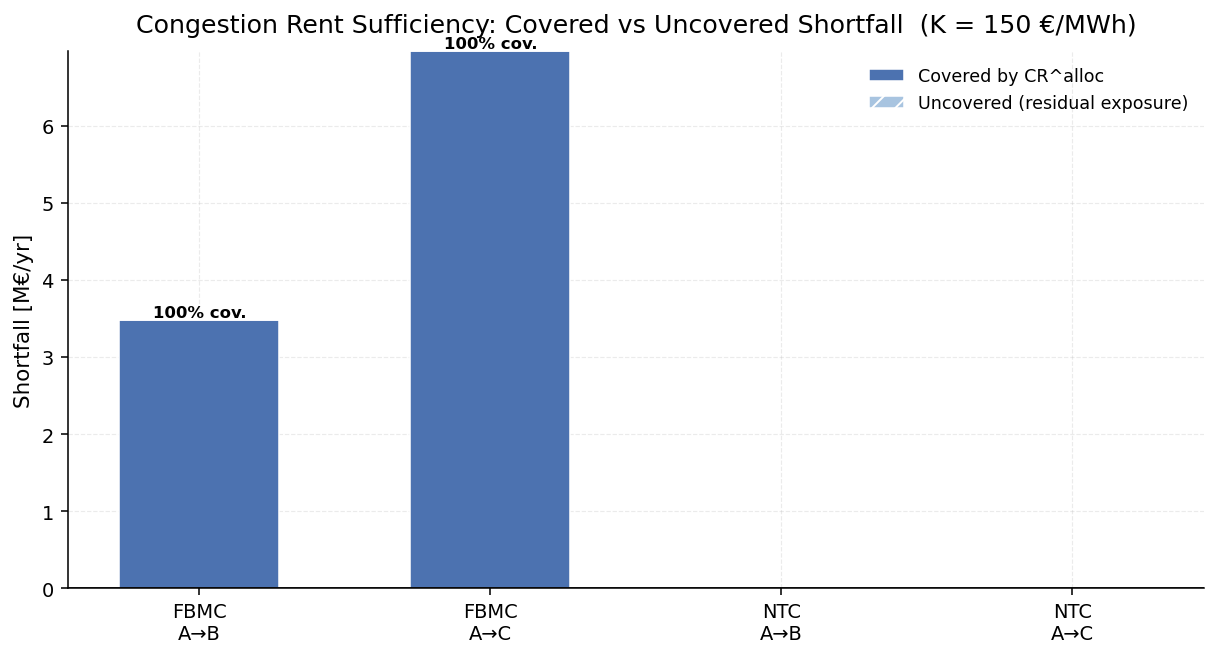

In [18]:
# Figure 5: covered vs uncovered shortfall — stacked bar per contract & design
if 'Annual_Shortfall_Covered_MEUR' not in summary.columns:
    print("Re-run RO_settlement.jl to generate the new hedging columns.")
else:
    fig_data = summary[summary["Design"].isin(SELECTED_DESIGNS)].copy()
    fig_data = fig_data.sort_values(["Design", "Contract"])
    fig_data["label"] = fig_data["Design"] + "\n" + fig_data["Contract"]

    x = np.arange(len(fig_data))
    width = 0.55
    palette_covered   = {'FBMC': '#4C72B0', 'NTC': '#D55E00'}
    palette_uncovered = {'FBMC': '#A8C4E0', 'NTC': '#F0A880'}

    fig, ax = plt.subplots(figsize=(max(7, 2.2 * len(fig_data)), 4.8))

    covered   = fig_data["Annual_Shortfall_Covered_MEUR"].fillna(0).values
    uncovered = fig_data["Annual_Shortfall_Uncovered_MEUR"].fillna(0).values
    designs   = fig_data["Design"].values

    bars_cov = ax.bar(x, covered,   width, label="Covered by CR^alloc",
                      color=[palette_covered.get(d, '#888') for d in designs],
                      edgecolor='white', linewidth=0.8)
    bars_unc = ax.bar(x, uncovered, width, bottom=covered, label="Uncovered (residual exposure)",
                      color=[palette_uncovered.get(d, '#ccc') for d in designs],
                      edgecolor='white', linewidth=0.8, hatch='//')

    # Annotate EUR coverage ratio on top of each bar
    for i, (cov, unc, d) in enumerate(zip(covered, uncovered, designs)):
        total = cov + unc
        if total > 1e-6:
            pct = cov / total * 100
            ax.text(i, total + 0.001, f"{pct:.0f}% cov.", ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(fig_data["label"], fontsize=10)
    ax.set_ylabel(f'Shortfall [M{EURO}/yr]')
    ax.set_title(f'Congestion Rent Sufficiency: Covered vs Uncovered Shortfall  (K = {K} {EURO}/MWh)', pad=10)
    ax.axhline(0, color='black', lw=0.8)
    ax.legend(frameon=False, fontsize=9, loc='upper right')
    ax.set_axisbelow(True)
    if SAVE_FIGURES:
        save_fig(fig, f'ro_hedge_sufficiency_K{K}.png')
    plt.tight_layout()
    plt.show()